# 🤖 Fluxos Inteligentes com Python + IA
## Etapa 4 — Geração do Relatório Final

Nesta etapa transformamos as classificações geradas na Etapa 3 em indicadores, relatórios e arquivos executivos, completando o pipeline:

**PDF → Extração → IA → Classificação → Indicadores → Relatórios**

---
**Bibliotecas:** `pandas`, `matplotlib`, `openpyxl`, `reportlab`

## 📦 1. Instalação das dependências

In [3]:
!pip install pandas matplotlib openpyxl reportlab --quiet
print('✅ Dependências instaladas!')

✅ Dependências instaladas!


## 📂 2. Carregando os resultados da Etapa 3

> ⚠️ **Pré-requisito:** Execute as Etapas 1, 2 e 3 antes desta.

Lemos diretamente o consolidado `classificacao_final.json` gerado na Etapa 3 e expandimos a lista de documentos em um DataFrame plano.

In [4]:
from pathlib import Path
from datetime import datetime
import json
import pandas as pd
import matplotlib.pyplot as plt

PASTA_RESULTADOS = Path('resultados')
PASTA_RESULTADOS.mkdir(exist_ok=True)

# Carrega o consolidado da Etapa 3
arquivo_consolidado = PASTA_RESULTADOS / 'classificacao_final.json'

if not arquivo_consolidado.exists():
    raise FileNotFoundError(
        f"Arquivo '{arquivo_consolidado}' não encontrado. "
        "Execute a Etapa 3 antes de continuar."
    )

with open(arquivo_consolidado, encoding='utf-8') as f:
    consolidado = json.load(f)

# Expande a lista de documentos diretamente em um DataFrame plano
df = pd.json_normalize(consolidado['documentos'])

# Resolve os nomes de coluna (dependem de como json_normalize aninhado funciona)
col_tipo  = 'classificacao.tipo_documento' if 'classificacao.tipo_documento' in df.columns else 'tipo_documento'
col_conf  = 'classificacao.confianca'      if 'classificacao.confianca'      in df.columns else 'confianca'
col_crit  = 'classificacao.itens_criticos' if 'classificacao.itens_criticos' in df.columns else 'itens_criticos'
col_status = 'classificacao.status'        if 'classificacao.status'         in df.columns else 'status'

gerado_em = consolidado.get('gerado_em', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))

print(f'✅ Consolidado carregado: {arquivo_consolidado}')
print(f'   Documentos : {len(df)}')
print(f'   Gerado em  : {gerado_em}')
print(f'   Colunas    : {list(df.columns)}')

✅ Consolidado carregado: resultados/classificacao_final.json
   Documentos : 7
   Gerado em  : 2026-05-29 18:05:14
   Colunas    : ['arquivo', 'tipo_original', 'classificado_em', 'status_parse', 'classificacao.tipo_documento', 'classificacao.confianca', 'classificacao.status', 'classificacao.resumo', 'classificacao.entidades.parte_1', 'classificacao.entidades.parte_2', 'classificacao.entidades.responsavel', 'classificacao.valores.principal', 'classificacao.valores.multa', 'classificacao.valores.outros', 'classificacao.datas.inicio', 'classificacao.datas.vencimento', 'classificacao.datas.assinatura', 'classificacao.indicadores', 'classificacao.itens_criticos']


## 🔍 3. Explorando os dados

Antes de gerar relatórios, validamos a estrutura e conferimos valores nulos.

In [5]:
print(df.dtypes)
print()
print('Nulos por coluna:')
print(df.isnull().sum())
print()
df[[col_tipo, col_conf, col_status, 'status_parse']].head(5)

arquivo                                object
tipo_original                          object
classificado_em                        object
status_parse                           object
classificacao.tipo_documento           object
classificacao.confianca                object
classificacao.status                   object
classificacao.resumo                   object
classificacao.entidades.parte_1        object
classificacao.entidades.parte_2        object
classificacao.entidades.responsavel    object
classificacao.valores.principal        object
classificacao.valores.multa            object
classificacao.valores.outros           object
classificacao.datas.inicio             object
classificacao.datas.vencimento         object
classificacao.datas.assinatura         object
classificacao.indicadores              object
classificacao.itens_criticos           object
dtype: object

Nulos por coluna:
arquivo                                0
tipo_original                          0
classificad

,classificacao.tipo_documento,classificacao.confianca,classificacao.status,status_parse
0,Nota Fiscal Eletrônica,alta,indefinido,ok
1,Nota Fiscal,alta,indefinido,ok
2,Ordem de Serviço,alta,encerrado,ok
3,Ordem de Serviço,alta,em andamento,ok
4,Ordem de Serviço,alta,pendente,ok


## 📊 4. Criando Indicadores Automáticos (KPIs)

Geramos métricas executivas a partir dos campos classificados.

In [6]:
def safe_len(x) -> bool:
    """Retorna True se x for uma lista não-vazia; ignora None e NaN."""
    try:
        return isinstance(x, list) and len(x) > 0
    except Exception:
        return False

kpis = {
    'Documentos Processados': len(df),
    'Parse com Sucesso':      (df['status_parse'] == 'ok').sum(),
    'Erros de Parse':         (df['status_parse'] != 'ok').sum(),
    'Tipos Distintos':        df[col_tipo].nunique() if col_tipo in df.columns else 0,
    'Com Itens Críticos':     df[col_crit].apply(safe_len).sum() if col_crit in df.columns else 0,
    'Confiança Alta':         (df[col_conf] == 'alta').sum() if col_conf in df.columns else 0,
    'Confiança Média':        (df[col_conf] == 'media').sum() if col_conf in df.columns else 0,
    'Confiança Baixa':        (df[col_conf] == 'baixa').sum() if col_conf in df.columns else 0,
}

print('─' * 40)
for k, v in kpis.items():
    print(f'  {k:<30}: {v}')
print('─' * 40)

────────────────────────────────────────
  Documentos Processados        : 7
  Parse com Sucesso             : 7
  Erros de Parse                : 0
  Tipos Distintos               : 5
  Com Itens Críticos            : 5
  Confiança Alta                : 7
  Confiança Média               : 0
  Confiança Baixa               : 0
────────────────────────────────────────


## 📈 5. Criando Gráficos

Dois gráficos: distribuição por tipo de documento e por nível de confiança.

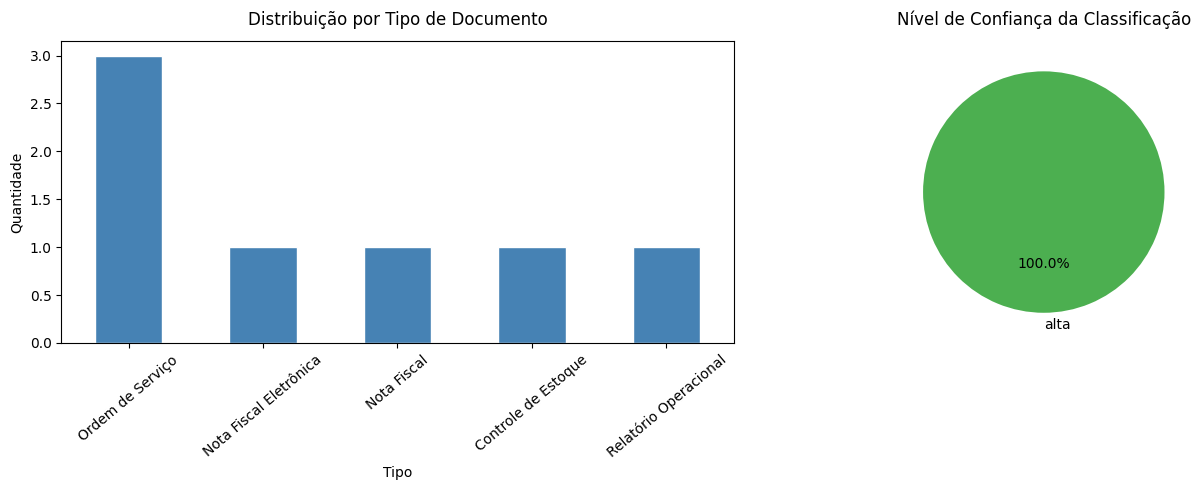

✅ Gráficos salvos em resultados/graficos_etapa4.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — Tipos de documento
if col_tipo in df.columns:
    contagem_tipo = df[col_tipo].value_counts()
    contagem_tipo.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_title('Distribuição por Tipo de Documento', fontsize=12, pad=12)
    axes[0].set_xlabel('Tipo')
    axes[0].set_ylabel('Quantidade')
    axes[0].tick_params(axis='x', rotation=40)
else:
    axes[0].set_visible(False)

# Gráfico 2 — Nível de confiança
if col_conf in df.columns:
    contagem_conf = df[col_conf].value_counts()
    cores = {'alta': '#4caf50', 'media': '#ff9800', 'baixa': '#f44336'}
    colors = [cores.get(c, '#90a4ae') for c in contagem_conf.index]
    contagem_conf.plot(kind='pie', ax=axes[1], colors=colors,
                       autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Nível de Confiança da Classificação', fontsize=12, pad=12)
    axes[1].set_ylabel('')
else:
    axes[1].set_visible(False)

plt.tight_layout()
plt.savefig(PASTA_RESULTADOS / 'graficos_etapa4.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráficos salvos em resultados/graficos_etapa4.png')

## 💾 6. Exportando Relatório Excel

Três abas: dados detalhados, KPIs e distribuição por tipo.

In [8]:
saida_excel = PASTA_RESULTADOS / 'relatorio_final.xlsx'

with pd.ExcelWriter(saida_excel, engine='openpyxl') as writer:

    # Aba 1 — Detalhes de todos os documentos
    df.to_excel(writer, sheet_name='Documentos', index=False)

    # Aba 2 — KPIs executivos
    df_kpis = pd.DataFrame(list(kpis.items()), columns=['Indicador', 'Valor'])
    df_kpis.to_excel(writer, sheet_name='Resumo_Executivo', index=False)

    # Aba 3 — Distribuição por tipo (se coluna disponível)
    if col_tipo in df.columns:
        df_tipos = (
            df[col_tipo]
            .value_counts()
            .rename_axis('Tipo')
            .reset_index(name='Quantidade')
        )
        df_tipos.to_excel(writer, sheet_name='Por_Tipo', index=False)

print(f'✅ Excel salvo: {saida_excel}')

✅ Excel salvo: resultados/relatorio_final.xlsx


## 📄 7. Criando Relatório PDF Executivo

Gera um PDF com KPIs, tabela de tipos e lista de documentos com itens críticos.

In [9]:
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, HRFlowable
)
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.pagesizes import letter
from reportlab.lib import colors
from reportlab.lib.units import cm

saida_pdf = str(PASTA_RESULTADOS / 'relatorio_executivo.pdf')
styles    = getSampleStyleSheet()
style_sub = ParagraphStyle('Sub', parent=styles['Heading2'], spaceAfter=6)

doc      = SimpleDocTemplate(saida_pdf, pagesize=letter,
                              leftMargin=2*cm, rightMargin=2*cm,
                              topMargin=2*cm, bottomMargin=2*cm)
conteudo = []

# Título
conteudo.append(Paragraph('Relatório Executivo de Documentos', styles['Title']))
conteudo.append(Paragraph(f'Gerado em: {gerado_em}', styles['Normal']))
conteudo.append(HRFlowable(width='100%', spaceAfter=12))

# Seção 1 — KPIs
conteudo.append(Paragraph('1. Indicadores Executivos', style_sub))
tabela_kpi = [['Indicador', 'Valor']] + [[k, str(v)] for k, v in kpis.items()]
t = Table(tabela_kpi, colWidths=[11*cm, 4*cm])
t.setStyle(TableStyle([
    ('BACKGROUND',  (0, 0), (-1, 0), colors.steelblue),
    ('TEXTCOLOR',   (0, 0), (-1, 0), colors.white),
    ('FONTNAME',    (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('ALIGN',       (1, 0), (1, -1), 'CENTER'),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.whitesmoke, colors.white]),
    ('GRID',        (0, 0), (-1, -1), 0.4, colors.lightgrey),
    ('FONTSIZE',    (0, 0), (-1, -1), 10),
    ('BOTTOMPADDING', (0, 0), (-1, -1), 5),
]))
conteudo.append(t)
conteudo.append(Spacer(1, 16))

# Seção 2 — Distribuição por tipo
if col_tipo in df.columns:
    conteudo.append(Paragraph('2. Distribuição por Tipo de Documento', style_sub))
    dist = df[col_tipo].value_counts()
    tabela_dist = [['Tipo de Documento', 'Qtd']] + [[tp, str(qt)] for tp, qt in dist.items()]
    t2 = Table(tabela_dist, colWidths=[11*cm, 4*cm])
    t2.setStyle(TableStyle([
        ('BACKGROUND',  (0, 0), (-1, 0), colors.steelblue),
        ('TEXTCOLOR',   (0, 0), (-1, 0), colors.white),
        ('FONTNAME',    (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('ALIGN',       (1, 0), (1, -1), 'CENTER'),
        ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.whitesmoke, colors.white]),
        ('GRID',        (0, 0), (-1, -1), 0.4, colors.lightgrey),
        ('FONTSIZE',    (0, 0), (-1, -1), 10),
        ('BOTTOMPADDING', (0, 0), (-1, -1), 5),
    ]))
    conteudo.append(t2)
    conteudo.append(Spacer(1, 16))

# Seção 3 — Documentos com itens críticos
criticos = df[df[col_crit].apply(safe_len)] if col_crit in df.columns else pd.DataFrame()
if not criticos.empty:
    conteudo.append(Paragraph('3. Documentos com Itens Críticos', style_sub))
    for _, row in criticos.iterrows():
        conteudo.append(Paragraph(f'<b>{row["arquivo"]}</b>', styles['BodyText']))
        for item in row[col_crit]:
            conteudo.append(Paragraph(f'  • {item}', styles['BodyText']))
        conteudo.append(Spacer(1, 6))

doc.build(conteudo)
print(f'✅ PDF executivo salvo: {saida_pdf}')

✅ PDF executivo salvo: resultados/relatorio_executivo.pdf


## 🔍 8. Validando os Arquivos Gerados

In [10]:
print("Arquivos na pasta 'resultados':")
for arq in sorted(PASTA_RESULTADOS.glob('*')):
    print(f'  {arq.name:<45} {arq.stat().st_size / 1024:>7.1f} KB')

Arquivos na pasta 'resultados':
  classificacao_final.json                          8.1 KB
  graficos_etapa4.png                              82.2 KB
  relatorio_executivo.pdf                           3.5 KB
  relatorio_final.xlsx                              8.1 KB


## ✅ 9. Resumo da Etapa 4

In [11]:
print('=' * 55)
print('  ETAPA 4 CONCLUÍDA — Geração de Relatórios')
print('=' * 55)
for k, v in kpis.items():
    print(f'  {k:<30}: {v}')
print()
print('  Arquivos gerados:')
print('    • resultados/relatorio_final.xlsx')
print('    • resultados/relatorio_executivo.pdf')
print('    • resultados/graficos_etapa4.png')
print('=' * 55)
print()
print('  🚀 Pipeline completo:')
print('  PDF → Extração → IA → Classificação → Relatórios')
print('=' * 55)

  ETAPA 4 CONCLUÍDA — Geração de Relatórios
  Documentos Processados        : 7
  Parse com Sucesso             : 7
  Erros de Parse                : 0
  Tipos Distintos               : 5
  Com Itens Críticos            : 5
  Confiança Alta                : 7
  Confiança Média               : 0
  Confiança Baixa               : 0

  Arquivos gerados:
    • resultados/relatorio_final.xlsx
    • resultados/relatorio_executivo.pdf
    • resultados/graficos_etapa4.png

  🚀 Pipeline completo:
  PDF → Extração → IA → Classificação → Relatórios


---
**Pipeline finalizado!** Você agora tem:

- `relatorio_final.xlsx` — dados detalhados para análise
- `relatorio_executivo.pdf` — resumo para gestão com tabelas e itens críticos
- `graficos_etapa4.png` — visualizações exportadas